In [14]:
import numpy as np
import pandas as pd
import hdbscan
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd 
import os

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA  # <-- Missing import
import matplotlib.pyplot as plt
#data load
raw_counts = pd.read_csv("gene_counts.csv", index_col=0)

In [15]:
raw_counts.head()

,Control,Control.1,Treatment,Treatment.1,Control.2,Control.3,Treatment,Treatment.2,Control.4,Control.5,Treatment .1,Treatment.3,Control.6,Control.7,Treatment.4,Treatment .2
GeneID,,,,,,,,,,,,,,,,
LOC101497325,1,8,7,3,0,1,1,7,16,12,10,29,21,20,3,4
LOC101488339,6,0,0,7,14,0,16,19,31,22,59,86,42,12,41,54
LOC101488545,52,131,74,79,68,2,87,111,135,98,160,136,74,85,85,85
LOC101497647,287,187,86,302,282,7,267,352,257,190,859,550,180,117,292,432
LOC101489113,338,638,1186,1621,652,28,658,560,1938,1489,1855,2137,1434,1311,1321,948


In [16]:
raw_counts.info

<bound method DataFrame.info of               Control  Control.1  Treatment  Treatment.1  Control.2  \
GeneID                                                                
LOC101497325        1          8          7            3          0   
LOC101488339        6          0          0            7         14   
LOC101488545       52        131         74           79         68   
LOC101497647      287        187         86          302        282   
LOC101489113      338        638       1186         1621        652   
...               ...        ...        ...          ...        ...   
CiarC_p072          0          0          0            0          0   
CiarC_p073          0          0          0            0          0   
CiarC_t029          0          0          0            0          0   
CiarC_p074          0          0          0            0          0   
CiarC_p075          0          0          0            0          0   

              Control.3  Treatment   Treatme

In [17]:
raw_counts.columns = raw_counts.columns.str.replace(r'^(Control|Treatment).*', r'\1', regex=True)
print("\nCleaned columns:")
print(raw_counts.columns)


Cleaned columns:
Index(['Control', 'Control', 'Treatment', 'Treatment', 'Control', 'Control',
       'Treatment', 'Treatment', 'Control', 'Control', 'Treatment',
       'Treatment', 'Control', 'Control', 'Treatment', 'Treatment'],
      dtype='object')


In [18]:
raw_counts.head()
raw_counts.info

<bound method DataFrame.info of               Control  Control  Treatment  Treatment  Control  Control  \
GeneID                                                                   
LOC101497325        1        8          7          3        0        1   
LOC101488339        6        0          0          7       14        0   
LOC101488545       52      131         74         79       68        2   
LOC101497647      287      187         86        302      282        7   
LOC101489113      338      638       1186       1621      652       28   
...               ...      ...        ...        ...      ...      ...   
CiarC_p072          0        0          0          0        0        0   
CiarC_p073          0        0          0          0        0        0   
CiarC_t029          0        0          0          0        0        0   
CiarC_p074          0        0          0          0        0        0   
CiarC_p075          0        0          0          0        0        0   

     

In [19]:
#filtered_df = raw_counts[raw_counts.ne(0).any(axis=1)]

In [20]:
filtered_df= raw_counts

In [21]:
filtered_df.info

<bound method DataFrame.info of               Control  Control  Treatment  Treatment  Control  Control  \
GeneID                                                                   
LOC101497325        1        8          7          3        0        1   
LOC101488339        6        0          0          7       14        0   
LOC101488545       52      131         74         79       68        2   
LOC101497647      287      187         86        302      282        7   
LOC101489113      338      638       1186       1621      652       28   
...               ...      ...        ...        ...      ...      ...   
CiarC_p072          0        0          0          0        0        0   
CiarC_p073          0        0          0          0        0        0   
CiarC_t029          0        0          0          0        0        0   
CiarC_p074          0        0          0          0        0        0   
CiarC_p075          0        0          0          0        0        0   

     

In [22]:
filtered_df.describe()

,Control,Control,Treatment,Treatment,Control,Control,Treatment,Treatment,Control,Control,Treatment,Treatment,Control,Control,Treatment,Treatment
count,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000,28581.000000
mean,528.577062,600.850250,573.449844,509.319863,522.448830,29.527623,508.646059,449.918162,671.282390,509.537945,481.950632,588.123754,575.540079,581.187257,539.759805,552.221791
std,8068.129956,6856.127101,4948.070899,6806.405839,4802.391712,437.077800,5379.110609,5844.825870,2783.904201,2374.680413,1529.966467,2205.154893,4052.482791,4231.230844,3210.770952,4281.215143
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,10.000000,12.000000,34.000000,30.000000,24.000000,1.000000,22.000000,16.000000,77.000000,63.000000,92.000000,95.000000,40.000000,36.000000,52.000000,40.000000
75%,90.000000,156.000000,284.000000,204.000000,209.000000,7.000000,163.000000,150.000000,497.000000,360.000000,463.000000,525.000000,310.000000,285.000000,353.000000,292.000000
max,956599.000000,493549.000000,431459.000000,797632.000000,351922.000000,34775.000000,400714.000000,744189.000000,151643.000000,139714.000000,65686.000000,110265.000000,258306.000000,249977.000000,240807.000000,428453.000000


In [23]:
normalized_data = np.log2(filtered_df + 1)

# ----------------------------

# ----------------------------
scaled_data = pd.DataFrame(
    StandardScaler().fit_transform(normalized_data.T).T,
    index=normalized_data.index,
    columns=normalized_data.columns
)

Original data shape: (28581, 16)
Top variable genes shape: (3000, 16)

Running with min_cluster_size=10, min_samples=10

Running with min_cluster_size=10, min_samples=20

Running with min_cluster_size=10, min_samples=30

Running with min_cluster_size=10, min_samples=40

Running with min_cluster_size=10, min_samples=50

Running with min_cluster_size=10, min_samples=60

Running with min_cluster_size=10, min_samples=70

Running with min_cluster_size=10, min_samples=80

Running with min_cluster_size=10, min_samples=90

Running with min_cluster_size=10, min_samples=100

Running with min_cluster_size=20, min_samples=10

Running with min_cluster_size=20, min_samples=20

Running with min_cluster_size=20, min_samples=30

Running with min_cluster_size=20, min_samples=40

Running with min_cluster_size=20, min_samples=50

Running with min_cluster_size=20, min_samples=60

Running with min_cluster_size=20, min_samples=70

Running with min_cluster_size=20, min_samples=80

Running with min_cluster_siz

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

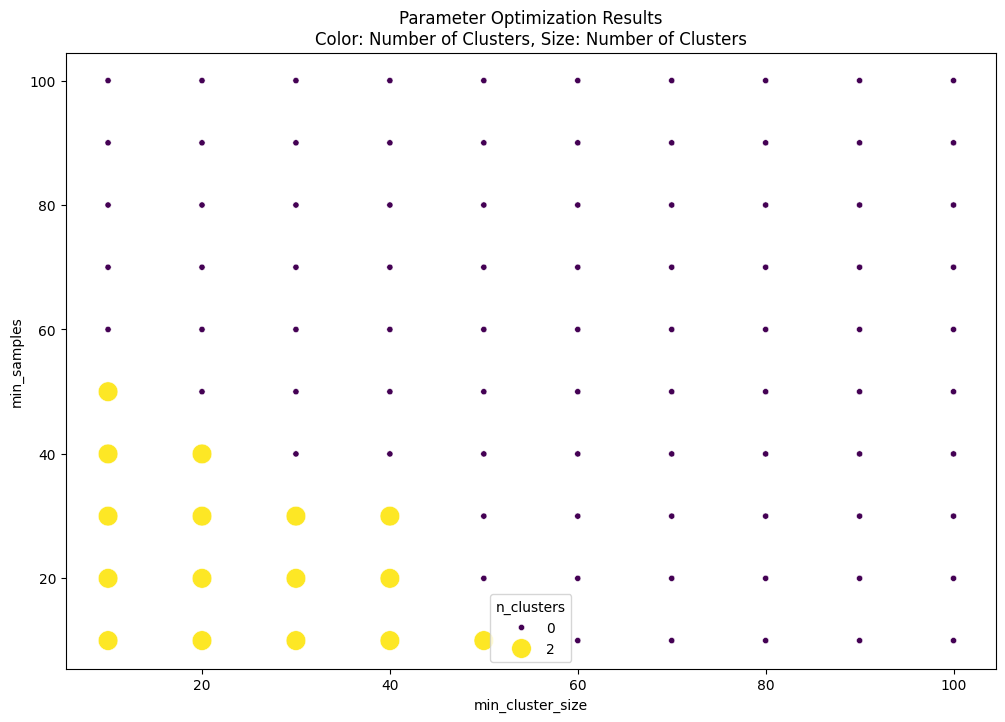

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import hdbscan
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from matplotlib.colors import LinearSegmentedColormap

# Create output directory
output_dir = "final_results_check2/PCA_optimization_visulaization_3k_mahalonobis"
os.makedirs(output_dir, exist_ok=True)

# Create custom red colormap
colors = [(0, 'white'), (0.5, 'lightcoral'), (1, 'darkred')]
red_cmap = LinearSegmentedColormap.from_list('red_cmap', colors)

# Assuming filtered_df is your original count matrix (genes × samples)
print(f"Original data shape: {filtered_df.shape}")

# 1. Log-normalization
normalized_data = np.log2(filtered_df + 1)

# 2. Select top variable genes
gene_variability = normalized_data.std(axis=1)
top_genes_idx = gene_variability.sort_values(ascending=False).head(3000).index
top_variable_data = normalized_data.loc[top_genes_idx]

print(f"Top variable genes shape: {top_variable_data.shape}")

# 3. Z-score normalization
top_variable_scaled = pd.DataFrame(
    StandardScaler().fit_transform(top_variable_data),
    index=top_genes_idx,
    columns=top_variable_data.columns
)

cov_matrix = np.cov(top_variable_scaled.T)
inv_cov_matrix = np.linalg.pinv(cov_matrix)

# Parameter ranges
min_cluster_sizes = range(10, 101, 10)
min_samples_range = range(10, 101, 10)

# Store optimization results
optimization_results = []

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_range:
        print(f"\nRunning with min_cluster_size={min_cluster_size}, min_samples={min_samples}")
        
        param_dir = os.path.join(output_dir, f"min_cluster_{min_cluster_size}_min_samples_{min_samples}")
        os.makedirs(param_dir, exist_ok=True)
        
        # HDBSCAN clustering
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric='mahalanobis',
            VI=inv_cov_matrix,
            gen_min_span_tree=True
        )
        clusters = clusterer.fit_predict(top_variable_scaled)
        
        # Store results
        optimization_results.append({
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'n_clusters': len(set(clusters)) - (1 if -1 in clusters else 0),
            'n_noise': sum(clusters == -1)
        })
        
        # Create cluster assignment dataframe
        cluster_assignments = pd.DataFrame({
            'Gene': top_variable_scaled.index,
            'Cluster': clusters
        })
        cluster_assignments.to_csv(
            os.path.join(param_dir, "all_gene_cluster_assignments.csv"),
            index=False
        )
        
        # Generate heatmaps for each cluster (including -1)
        for cluster_id in np.unique(clusters):
            cluster_name = "Outliers" if cluster_id == -1 else f"Cluster_{cluster_id}"
            cluster_genes = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]['Gene']
            
            if len(cluster_genes) > 0:
                # Save gene list
                pd.DataFrame({'Gene': cluster_genes}).to_csv(
                    os.path.join(param_dir, f"{cluster_name}_genes.csv"),
                    index=False
                )
                
                # Create heatmap for this cluster
                cluster_data = top_variable_scaled.loc[cluster_genes]
                
                plt.figure(figsize=(15, 10))
                # Create gridspec to position colorbar below heatmap
                gs = plt.GridSpec(2, 1, height_ratios=[0.9, 0.1])
                ax0 = plt.subplot(gs[0])
                ax1 = plt.subplot(gs[1])
                
                # Main heatmap
                sns.heatmap(
                    cluster_data,
                    cmap=red_cmap,
                    yticklabels=False,
                    cbar=False,
                    ax=ax0,
                    center=0,
                    vmin=-3,
                    vmax=3
                )
                ax0.set_title(f"Expression Heatmap - {cluster_name} (n={len(cluster_genes)})")
                ax0.set_xlabel("")
                
                # Add colorbar below
                cbar = plt.colorbar(ax0.collections[0], cax=ax1, orientation='horizontal')
                cbar.set_label('Z-score normalized expression', labelpad=10)
                cbar.ax.xaxis.set_ticks_position('bottom')
                cbar.ax.xaxis.set_label_position('bottom')
                
                plt.tight_layout()
                plt.savefig(
                    os.path.join(param_dir, f"{cluster_name}_heatmap.png"),
                    dpi=300, bbox_inches='tight'
                )
                plt.close()
        
        # Perform PCA for visualization
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(top_variable_scaled)
        pca_df = pd.DataFrame({
            'PC1': pca_result[:, 0],
            'PC2': pca_result[:, 1],
            'Cluster': clusters
        })
        
        # 1. PCA plot for all clusters
        plt.figure(figsize=(12, 8))
        unique_clusters = np.unique(clusters)
        palette = sns.color_palette("hsv", len(unique_clusters)-1) + [(0.5, 0.5, 0.5)]  # Gray for outliers
        
        sns.scatterplot(
            data=pca_df,
            x='PC1',
            y='PC2',
            hue='Cluster',
            palette=palette,
            alpha=0.7,
            s=50
        )
        plt.title(f"PCA of Gene Clusters\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
        plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(
            os.path.join(param_dir, "pca_all_clusters.png"),
            dpi=300, bbox_inches='tight'
        )
        plt.close()
        
        # 2. PCA plot for ONLY outliers (-1 cluster)
        if -1 in clusters:
            outliers_df = pca_df[pca_df['Cluster'] == -1]
            plt.figure(figsize=(12, 8))
            sns.scatterplot(
                data=outliers_df,
                x='PC1',
                y='PC2',
                color='gray',
                alpha=0.7,
                s=50)
            plt.title(f"PCA of Outlier Genes Only\n(min_cluster_size={min_cluster_size}, min_samples={min_samples}, n={len(outliers_df)})")
            plt.tight_layout()
            plt.savefig(
                os.path.join(param_dir, "pca_outliers_only.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        
        # Generate dendrogram using scipy
        try:
            # Subsample if too many genes for dendrogram
            if len(top_variable_scaled) > 1000:
                sample_idx = np.random.choice(len(top_variable_scaled), 1000, replace=False)
                sample_data = top_variable_scaled.iloc[sample_idx]
            else:
                sample_data = top_variable_scaled
            
            distance_matrix = pdist(sample_data, 'euclidean')
            linkage_matrix = linkage(distance_matrix, 'ward')
            
            plt.figure(figsize=(20, 12))
            dendrogram(
                linkage_matrix,
                truncate_mode='lastp',
                p=min(50, len(sample_data)),  # show only the last p merged clusters
                show_leaf_counts=True,
                leaf_rotation=90,
                leaf_font_size=8,
                show_contracted=True,
                color_threshold=0.7*max(linkage_matrix[:, 2])
            )
            
            # Add cluster colors if we have cluster assignments
            if hasattr(clusterer, 'labels_'):
                cluster_colors = [sns.color_palette("hsv", len(set(clusters)))[i] 
                                if i != -1 else (0.5, 0.5, 0.5)
                                for i in clusters[sample_idx]]
                ax = plt.gca()
                xlbls = ax.get_xmajorticklabels()
                for lbl, color in zip(xlbls, cluster_colors):
                    lbl.set_color(color)
            
            plt.title(f"Gene Cluster Dendrogram\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
            plt.xlabel("Gene Clusters")
            plt.ylabel("Distance")
            plt.savefig(
                os.path.join(param_dir, "gene_cluster_dendrogram.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        except Exception as e:
            print(f"Could not create dendrogram: {e}")

# Save optimization results
optimization_df = pd.DataFrame(optimization_results)
optimization_df.to_csv(os.path.join(output_dir, "parameter_optimization_results.csv"), index=False)

# Plot optimization summary
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=optimization_df,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='viridis',
    sizes=(20, 200)
)
plt.title("Parameter Optimization Results\nColor: Number of Clusters, Size: Number of Clusters")
plt.colorbar(label='Number of Clusters')
plt.savefig(os.path.join(output_dir, "parameter_optimization_summary.png"), dpi=300)
plt.close()

print(f"\nAll results saved to: {output_dir}")

In [27]:
data1= pd.read_csv ("final_results_check2/PCA_optimization_visulaization_3k_mahalonobis/parameter_optimization_results.csv")

In [28]:
data1.head()

,min_cluster_size,min_samples,n_clusters,n_noise
0,10,10,2,675
1,10,20,2,743
2,10,30,2,775
3,10,40,2,850
4,10,50,2,755


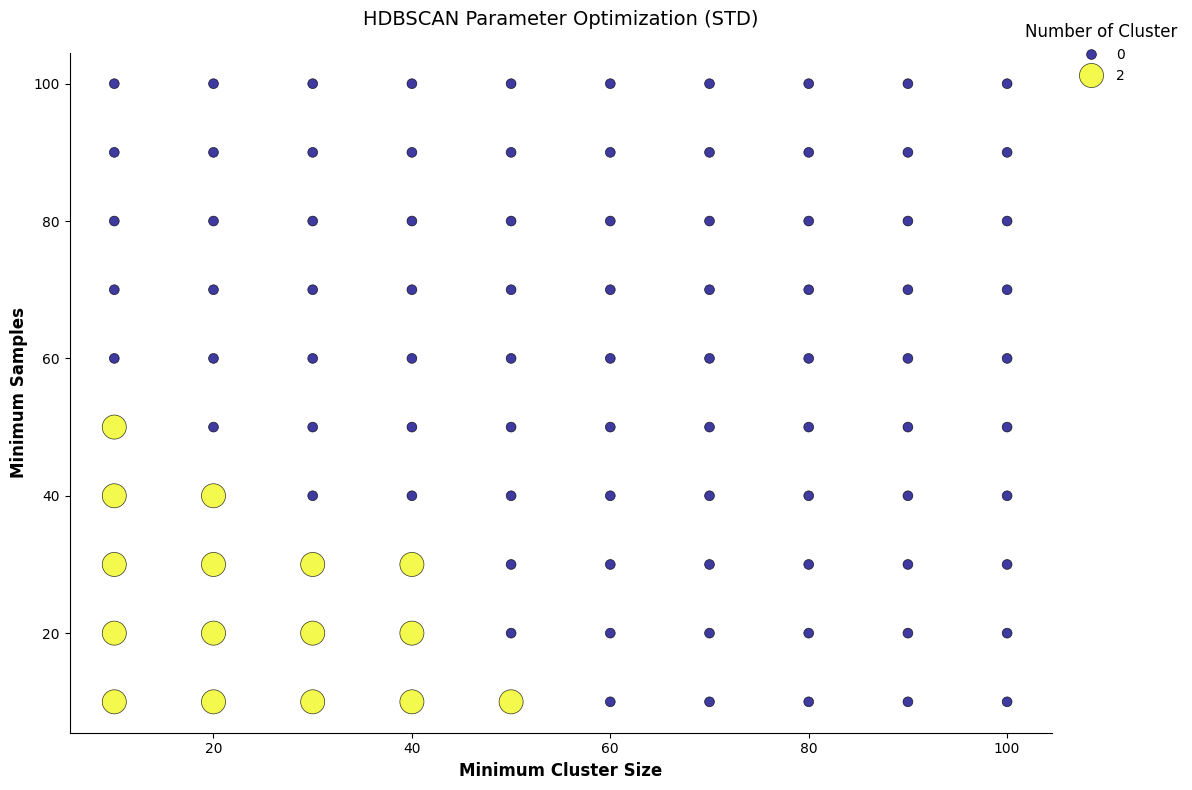

In [30]:

data1= pd.read_csv ("final_results_check2/PCA_optimization_visulaization_3k_mahalonobis/parameter_optimization_results.csv")

plt.figure(figsize=(12, 8))

# Create scatterplot
scatter = sns.scatterplot(
    data=data1,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='plasma',
    sizes=(50, 300),
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)

# Customize axis labels & title
plt.xlabel("Minimum Cluster Size", fontsize=12, weight='bold')
plt.ylabel("Minimum Samples", fontsize=12, weight='bold')
plt.title("HDBSCAN Parameter Optimization (STD)", fontsize=14, pad=20)

# Remove top and right spines (borders)
ax = plt.gca()  # Get current axis
ax.spines['top'].set_visible(False)     # Hide top border
ax.spines['right'].set_visible(False)  # Hide right border
ax.spines['left'].set_color('black')   # Left axis: black line
ax.spines['bottom'].set_color('black') # Bottom axis: black line

# Modify legend title and position
# Customize legends
legend_hue = scatter.legend_
legend_hue.set_title("Clusters", prop={'size': 12, 'weight': 'bold'})
for text in legend_hue.get_texts():
    text.set_fontsize(10)

plt.legend(
    title='Number of Cluster',
    title_fontsize=12,
    fontsize=10,
    bbox_to_anchor=(1.05, 1),
    loc='center',
    frameon=False  # No legend border
)
# Save and show
plt.tight_layout()
plt.savefig(
    "final_results_check2/PCA_optimization_visulaization_3k_mahalonobis/parameter_optimization_summary.png",
    dpi=300,
    bbox_inches='tight',
    transparent=True  # Remove background (if needed)
)
plt.show()
plt.close()


Original data shape: (28581, 16)

Running with min_cluster_size=10, min_samples=10

Running with min_cluster_size=10, min_samples=20

Running with min_cluster_size=10, min_samples=30

Running with min_cluster_size=10, min_samples=40

Running with min_cluster_size=10, min_samples=50

Running with min_cluster_size=10, min_samples=60

Running with min_cluster_size=10, min_samples=70

Running with min_cluster_size=10, min_samples=80

Running with min_cluster_size=10, min_samples=90

Running with min_cluster_size=10, min_samples=100

Running with min_cluster_size=20, min_samples=10

Running with min_cluster_size=20, min_samples=20

Running with min_cluster_size=20, min_samples=30

Running with min_cluster_size=20, min_samples=40

Running with min_cluster_size=20, min_samples=50

Running with min_cluster_size=20, min_samples=60

Running with min_cluster_size=20, min_samples=70

Running with min_cluster_size=20, min_samples=80

Running with min_cluster_size=20, min_samples=90

Running with mi

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

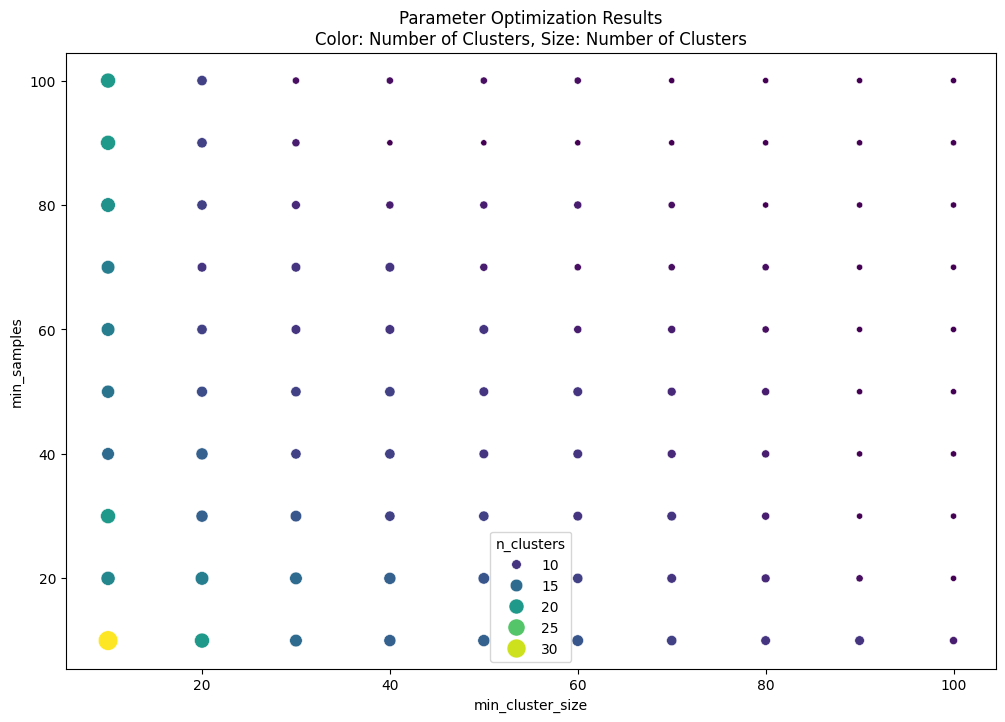

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import hdbscan
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from matplotlib.colors import LinearSegmentedColormap

# Create output directory
output_dir = "final_results/PCA_optimization_visulaization_on_all_via_manhttan"
os.makedirs(output_dir, exist_ok=True)

# Create custom red colormap
colors = [(0, 'white'), (0.5, 'lightcoral'), (1, 'darkred')]
red_cmap = LinearSegmentedColormap.from_list('red_cmap', colors)

# Assuming filtered_df is your original count matrix (genes × samples)
print(f"Original data shape: {filtered_df.shape}")

# 1. Log-normalization
normalized_data = np.log2(filtered_df + 1)
top_genes_idx = normalized_data.index
top_variable_data = normalized_data.loc[top_genes_idx]

# 3. Z-score normalization
top_variable_scaled = pd.DataFrame(
    StandardScaler().fit_transform(normalized_data),
    index=top_genes_idx,
    columns=top_variable_data.columns
)

# Parameter ranges
min_cluster_sizes = range(10, 101, 10)
min_samples_range = range(10, 101, 10)

# Store optimization results
optimization_results = []

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_range:
        print(f"\nRunning with min_cluster_size={min_cluster_size}, min_samples={min_samples}")
        
        param_dir = os.path.join(output_dir, f"min_cluster_{min_cluster_size}_min_samples_{min_samples}")
        os.makedirs(param_dir, exist_ok=True)
        
        # HDBSCAN clustering
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric = 'manhattan',
            gen_min_span_tree=True
        )
        clusters = clusterer.fit_predict(top_variable_scaled)
        
        # Store results
        optimization_results.append({
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'n_clusters': len(set(clusters)) - (1 if -1 in clusters else 0),
            'n_noise': sum(clusters == -1)
        })
        
        # Create cluster assignment dataframe
        cluster_assignments = pd.DataFrame({
            'Gene': top_variable_scaled.index,
            'Cluster': clusters
        })
        cluster_assignments.to_csv(
            os.path.join(param_dir, "all_gene_cluster_assignments.csv"),
            index=False
        )
        
        # Generate heatmaps for each cluster (including -1)
        for cluster_id in np.unique(clusters):
            cluster_name = "Outliers" if cluster_id == -1 else f"Cluster_{cluster_id}"
            cluster_genes = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]['Gene']
            
            if len(cluster_genes) > 0:
                # Save gene list
                pd.DataFrame({'Gene': cluster_genes}).to_csv(
                    os.path.join(param_dir, f"{cluster_name}_genes.csv"),
                    index=False
                )
                
                # Create heatmap for this cluster
                cluster_data = top_variable_scaled.loc[cluster_genes]
                
                plt.figure(figsize=(15, 10))
                # Create gridspec to position colorbar below heatmap
                gs = plt.GridSpec(2, 1, height_ratios=[0.9, 0.1])
                ax0 = plt.subplot(gs[0])
                ax1 = plt.subplot(gs[1])
                
                # Main heatmap
                sns.heatmap(
                    cluster_data,
                    cmap=red_cmap,
                    yticklabels=False,
                    cbar=False,
                    ax=ax0,
                    center=0,
                    vmin=-3,
                    vmax=3
                )
                ax0.set_title(f"Expression Heatmap - {cluster_name} (n={len(cluster_genes)})")
                ax0.set_xlabel("")
                
                # Add colorbar below
                cbar = plt.colorbar(ax0.collections[0], cax=ax1, orientation='horizontal')
                cbar.set_label('Z-score normalized expression', labelpad=10)
                cbar.ax.xaxis.set_ticks_position('bottom')
                cbar.ax.xaxis.set_label_position('bottom')
                
                plt.tight_layout()
                plt.savefig(
                    os.path.join(param_dir, f"{cluster_name}_heatmap.png"),
                    dpi=300, bbox_inches='tight'
                )
                plt.close()
        
        # Perform PCA for visualization
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(top_variable_scaled)
        pca_df = pd.DataFrame({
            'PC1': pca_result[:, 0],
            'PC2': pca_result[:, 1],
            'Cluster': clusters
        })
        
        # 1. PCA plot for all clusters
        plt.figure(figsize=(12, 8))
        unique_clusters = np.unique(clusters)
        palette = sns.color_palette("hsv", len(unique_clusters)-1) + [(0.5, 0.5, 0.5)]  # Gray for outliers
        
        sns.scatterplot(
            data=pca_df,
            x='PC1',
            y='PC2',
            hue='Cluster',
            palette=palette,
            alpha=0.7,
            s=50
        )
        plt.title(f"PCA of Gene Clusters\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
        plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(
            os.path.join(param_dir, "pca_all_clusters.png"),
            dpi=300, bbox_inches='tight'
        )
        plt.close()
        
        # 2. PCA plot for ONLY outliers (-1 cluster)
        if -1 in clusters:
            outliers_df = pca_df[pca_df['Cluster'] == -1]
            plt.figure(figsize=(12, 8))
            sns.scatterplot(
                data=outliers_df,
                x='PC1',
                y='PC2',
                color='gray',
                alpha=0.7,
                s=50
            )
            plt.title(f"PCA of Outlier Genes Only\n(min_cluster_size={min_cluster_size}, min_samples={min_samples}, n={len(outliers_df)})")
            plt.tight_layout()
            plt.savefig(
                os.path.join(param_dir, "pca_outliers_only.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        
        # Generate dendrogram using scipy
        try:
            # Subsample if too many genes for dendrogram
            if len(top_variable_scaled) > 1000:
                sample_idx = np.random.choice(len(top_variable_scaled), 1000, replace=False)
                sample_data = top_variable_scaled.iloc[sample_idx]
            else:
                sample_data = top_variable_scaled
            
            distance_matrix = pdist(sample_data, 'euclidean')
            linkage_matrix = linkage(distance_matrix, 'ward')
            
            plt.figure(figsize=(20, 12))
            dendrogram(
                linkage_matrix,
                truncate_mode='lastp',
                p=min(50, len(sample_data)),  # show only the last p merged clusters
                show_leaf_counts=True,
                leaf_rotation=90,
                leaf_font_size=8,
                show_contracted=True,
                color_threshold=0.7*max(linkage_matrix[:, 2])
            )
            
            # Add cluster colors if we have cluster assignments
            if hasattr(clusterer, 'labels_'):
                cluster_colors = [sns.color_palette("hsv", len(set(clusters)))[i] 
                                if i != -1 else (0.5, 0.5, 0.5)
                                for i in clusters[sample_idx]]
                ax = plt.gca()
                xlbls = ax.get_xmajorticklabels()
                for lbl, color in zip(xlbls, cluster_colors):
                    lbl.set_color(color)
            
            plt.title(f"Gene Cluster Dendrogram\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
            plt.xlabel("Gene Clusters")
            plt.ylabel("Distance")
            plt.savefig(
                os.path.join(param_dir, "gene_cluster_dendrogram.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        except Exception as e:
            print(f"Could not create dendrogram: {e}")

# Save optimization results
optimization_df = pd.DataFrame(optimization_results)
optimization_df.to_csv(os.path.join(output_dir, "parameter_optimization_results.csv"), index=False)

# Plot optimization summary
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=optimization_df,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='viridis',
    sizes=(20, 200)
)
plt.title("Parameter Optimization Results\nColor: Number of Clusters, Size: Number of Clusters")
plt.colorbar(label='Number of Clusters')
plt.savefig(os.path.join(output_dir, "parameter_optimization_summary.png"), dpi=300)
plt.close()

print(f"\nAll results saved to: {output_dir}")

In [40]:
data1= pd.read_csv ("final_results/PCA_optimization_visulaization_on_all_via_manhttan/parameter_optimization_results.csv")


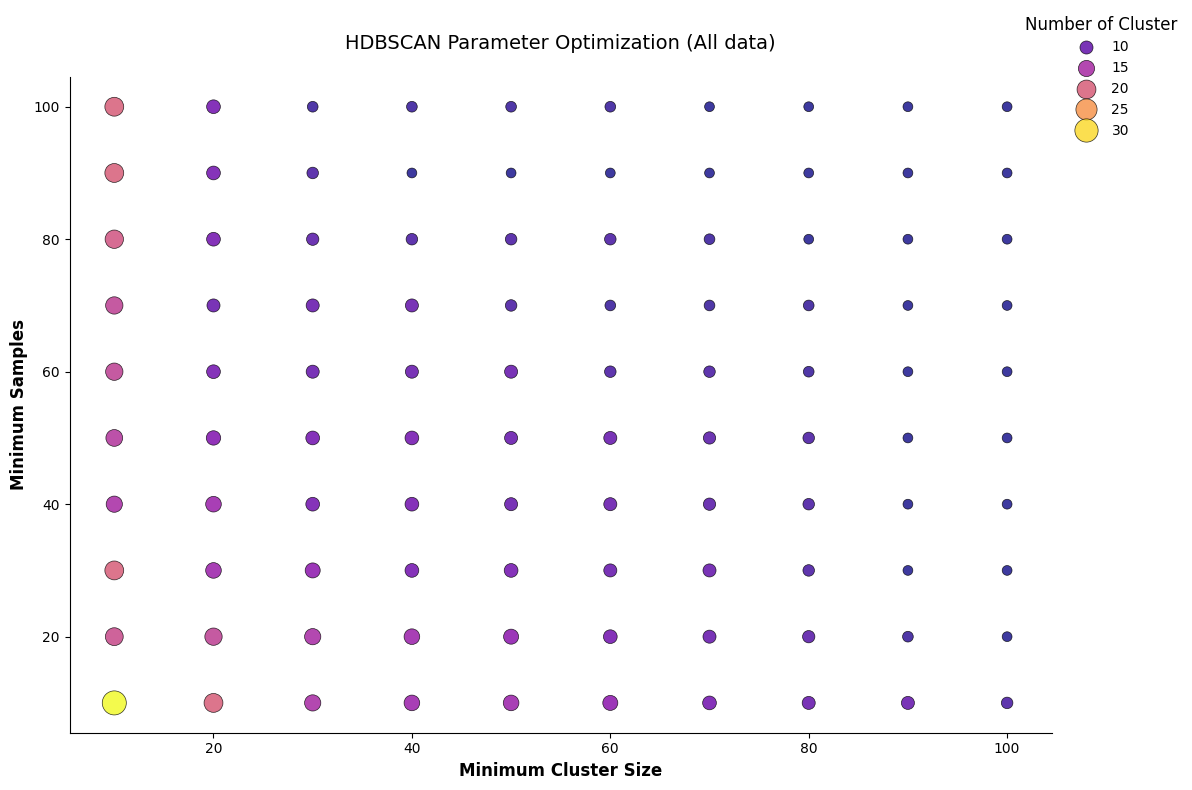

In [42]:

data1= pd.read_csv ("final_results/PCA_optimization_visulaization_on_all_via_manhttan/parameter_optimization_results.csv")

plt.figure(figsize=(12, 8))

# Create scatterplot
scatter = sns.scatterplot(
    data=data1,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='plasma',
    sizes=(50, 300),
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)

# Customize axis labels & title
plt.xlabel("Minimum Cluster Size", fontsize=12, weight='bold')
plt.ylabel("Minimum Samples", fontsize=12, weight='bold')
plt.title("HDBSCAN Parameter Optimization (All data)", fontsize=14, pad=20)

# Remove top and right spines (borders)
ax = plt.gca()  # Get current axis
ax.spines['top'].set_visible(False)     # Hide top border
ax.spines['right'].set_visible(False)  # Hide right border
ax.spines['left'].set_color('black')   # Left axis: black line
ax.spines['bottom'].set_color('black') # Bottom axis: black line

# Modify legend title and position
# Customize legends
legend_hue = scatter.legend_
legend_hue.set_title("Clusters", prop={'size': 12, 'weight': 'bold'})
for text in legend_hue.get_texts():
    text.set_fontsize(10)

plt.legend(
    title='Number of Cluster',
    title_fontsize=12,
    fontsize=10,
    bbox_to_anchor=(1.05, 1),
    loc='center',
    frameon=False  # No legend border
)
# Save and show
plt.tight_layout()
plt.savefig(
    "final_results/PCA_optimization_visulaization_on_all_via_manhttan/parameter_optimization_results.PNG",
    dpi=300,
    bbox_inches='tight',
    transparent=True  # Remove background (if needed)
)
plt.show()
plt.close()


Original data shape: (28581, 16)
Top variable genes shape: (5000, 16)

Running with min_cluster_size=10, min_samples=10

Running with min_cluster_size=10, min_samples=20

Running with min_cluster_size=10, min_samples=30

Running with min_cluster_size=10, min_samples=40

Running with min_cluster_size=10, min_samples=50

Running with min_cluster_size=10, min_samples=60

Running with min_cluster_size=10, min_samples=70

Running with min_cluster_size=10, min_samples=80

Running with min_cluster_size=10, min_samples=90

Running with min_cluster_size=10, min_samples=100

Running with min_cluster_size=20, min_samples=10

Running with min_cluster_size=20, min_samples=20

Running with min_cluster_size=20, min_samples=30

Running with min_cluster_size=20, min_samples=40

Running with min_cluster_size=20, min_samples=50

Running with min_cluster_size=20, min_samples=60

Running with min_cluster_size=20, min_samples=70

Running with min_cluster_size=20, min_samples=80

Running with min_cluster_siz

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

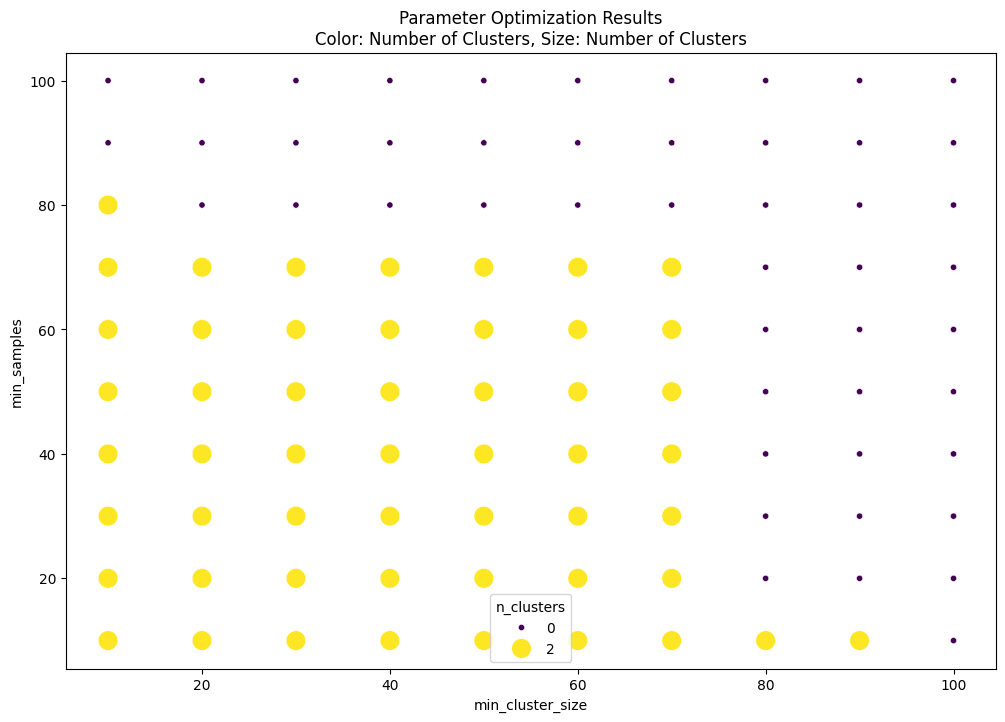

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import hdbscan
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from matplotlib.colors import LinearSegmentedColormap

# Create output directory
output_dir = "final_results/PCA_optimization_visulaization_with_5K_via_EU"
os.makedirs(output_dir, exist_ok=True)

# Create custom red colormap
colors = [(0, 'white'), (0.5, 'lightcoral'), (1, 'darkred')]
red_cmap = LinearSegmentedColormap.from_list('red_cmap', colors)

# Assuming filtered_df is your original count matrix (genes × samples)
print(f"Original data shape: {filtered_df.shape}")

# 1. Log-normalization
normalized_data = np.log2(filtered_df + 1)

# 2. Select top variable genes
gene_variability = normalized_data.std(axis=1)
top_genes_idx = gene_variability.sort_values(ascending=False).head(5000).index
top_variable_data = normalized_data.loc[top_genes_idx]

print(f"Top variable genes shape: {top_variable_data.shape}")

# 3. Z-score normalization
top_variable_scaled = pd.DataFrame(
    StandardScaler().fit_transform(top_variable_data),
    index=top_genes_idx,
    columns=top_variable_data.columns
)

# Parameter ranges
min_cluster_sizes = range(10, 101, 10)
min_samples_range = range(10, 101, 10)

# Store optimization results
optimization_results = []

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_range:
        print(f"\nRunning with min_cluster_size={min_cluster_size}, min_samples={min_samples}")
        
        param_dir = os.path.join(output_dir, f"min_cluster_{min_cluster_size}_min_samples_{min_samples}")
        os.makedirs(param_dir, exist_ok=True)
        
        # HDBSCAN clustering
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            gen_min_span_tree=True
        )
        clusters = clusterer.fit_predict(top_variable_scaled)
        
        # Store results
        optimization_results.append({
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'n_clusters': len(set(clusters)) - (1 if -1 in clusters else 0),
            'n_noise': sum(clusters == -1)
        })
        
        # Create cluster assignment dataframe
        cluster_assignments = pd.DataFrame({
            'Gene': top_variable_scaled.index,
            'Cluster': clusters
        })
        cluster_assignments.to_csv(
            os.path.join(param_dir, "all_gene_cluster_assignments.csv"),
            index=False
        )
        
        # Generate heatmaps for each cluster (including -1)
        for cluster_id in np.unique(clusters):
            cluster_name = "Outliers" if cluster_id == -1 else f"Cluster_{cluster_id}"
            cluster_genes = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]['Gene']
            
            if len(cluster_genes) > 0:
                # Save gene list
                pd.DataFrame({'Gene': cluster_genes}).to_csv(
                    os.path.join(param_dir, f"{cluster_name}_genes.csv"),
                    index=False
                )
                
                # Create heatmap for this cluster
                cluster_data = top_variable_scaled.loc[cluster_genes]
                
                plt.figure(figsize=(15, 10))
                # Create gridspec to position colorbar below heatmap
                gs = plt.GridSpec(2, 1, height_ratios=[0.9, 0.1])
                ax0 = plt.subplot(gs[0])
                ax1 = plt.subplot(gs[1])
                
                # Main heatmap
                sns.heatmap(
                    cluster_data,
                    cmap=red_cmap,
                    yticklabels=False,
                    cbar=False,
                    ax=ax0,
                    center=0,
                    vmin=-3,
                    vmax=3
                )
                ax0.set_title(f"Expression Heatmap - {cluster_name} (n={len(cluster_genes)})")
                ax0.set_xlabel("")
                
                # Add colorbar below
                cbar = plt.colorbar(ax0.collections[0], cax=ax1, orientation='horizontal')
                cbar.set_label('Z-score normalized expression', labelpad=10)
                cbar.ax.xaxis.set_ticks_position('bottom')
                cbar.ax.xaxis.set_label_position('bottom')
                
                plt.tight_layout()
                plt.savefig(
                    os.path.join(param_dir, f"{cluster_name}_heatmap.png"),
                    dpi=300, bbox_inches='tight'
                )
                plt.close()
        
        # Perform PCA for visualization
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(top_variable_scaled)
        pca_df = pd.DataFrame({
            'PC1': pca_result[:, 0],
            'PC2': pca_result[:, 1],
            'Cluster': clusters
        })
        
        # 1. PCA plot for all clusters
        plt.figure(figsize=(12, 8))
        unique_clusters = np.unique(clusters)
        palette = sns.color_palette("hsv", len(unique_clusters)-1) + [(0.5, 0.5, 0.5)]  # Gray for outliers
        
        sns.scatterplot(
            data=pca_df,
            x='PC1',
            y='PC2',
            hue='Cluster',
            palette=palette,
            alpha=0.7,
            s=50
        )
        plt.title(f"PCA of Gene Clusters\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
        plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(
            os.path.join(param_dir, "pca_all_clusters.png"),
            dpi=300, bbox_inches='tight'
        )
        plt.close()
        
        # 2. PCA plot for ONLY outliers (-1 cluster)
        if -1 in clusters:
            outliers_df = pca_df[pca_df['Cluster'] == -1]
            plt.figure(figsize=(12, 8))
            sns.scatterplot(
                data=outliers_df,
                x='PC1',
                y='PC2',
                color='gray',
                alpha=0.7,
                s=50
            )
            plt.title(f"PCA of Outlier Genes Only\n(min_cluster_size={min_cluster_size}, min_samples={min_samples}, n={len(outliers_df)})")
            plt.tight_layout()
            plt.savefig(
                os.path.join(param_dir, "pca_outliers_only.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        
        # Generate dendrogram using scipy
        try:
            # Subsample if too many genes for dendrogram
            if len(top_variable_scaled) > 1000:
                sample_idx = np.random.choice(len(top_variable_scaled), 1000, replace=False)
                sample_data = top_variable_scaled.iloc[sample_idx]
            else:
                sample_data = top_variable_scaled
            
            distance_matrix = pdist(sample_data, 'euclidean')
            linkage_matrix = linkage(distance_matrix, 'ward')
            
            plt.figure(figsize=(20, 12))
            dendrogram(
                linkage_matrix,
                truncate_mode='lastp',
                p=min(50, len(sample_data)),  # show only the last p merged clusters
                show_leaf_counts=True,
                leaf_rotation=90,
                leaf_font_size=8,
                show_contracted=True,
                color_threshold=0.7*max(linkage_matrix[:, 2])
            )
            
            # Add cluster colors if we have cluster assignments
            if hasattr(clusterer, 'labels_'):
                cluster_colors = [sns.color_palette("hsv", len(set(clusters)))[i] 
                                if i != -1 else (0.5, 0.5, 0.5)
                                for i in clusters[sample_idx]]
                ax = plt.gca()
                xlbls = ax.get_xmajorticklabels()
                for lbl, color in zip(xlbls, cluster_colors):
                    lbl.set_color(color)
            
            plt.title(f"Gene Cluster Dendrogram\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
            plt.xlabel("Gene Clusters")
            plt.ylabel("Distance")
            plt.savefig(
                os.path.join(param_dir, "gene_cluster_dendrogram.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        except Exception as e:
            print(f"Could not create dendrogram: {e}")

# Save optimization results
optimization_df = pd.DataFrame(optimization_results)
optimization_df.to_csv(os.path.join(output_dir, "parameter_optimization_results.csv"), index=False)

# Plot optimization summary
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=optimization_df,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='viridis',
    sizes=(20, 200)
)
plt.title("Parameter Optimization Results\nColor: Number of Clusters, Size: Number of Clusters")
plt.colorbar(label='Number of Clusters')
plt.savefig(os.path.join(output_dir, "parameter_optimization_summary.png"), dpi=300)
plt.close()

print(f"\nAll results saved to: {output_dir}")

In [44]:
data1= pd.read_csv ("final_results/PCA_optimization_visulaization_with_5K_via_EU/parameter_optimization_results.csv")
data1.head()

,min_cluster_size,min_samples,n_clusters,n_noise
0,10,10,2,470
1,10,20,2,684
2,10,30,2,750
3,10,40,2,763
4,10,50,2,796


In [ ]:

data1= pd.read_csv ("final_results/PCA_optimization_visulaization_with_5K__via_EU/parameter_optimization_results.csv")

plt.figure(figsize=(12, 8))

# Create scatterplot
scatter = sns.scatterplot(
    data=data1,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='plasma',
    sizes=(50, 300),
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)

# Customize axis labels & title
plt.xlabel("Minimum Cluster Size", fontsize=12, weight='bold')
plt.ylabel("Minimum Samples", fontsize=12, weight='bold')
plt.title("HDBSCAN Parameter Optimization (STD 5K)", fontsize=14, pad=20)

# Remove top and right spines (borders)
ax = plt.gca()  # Get current axis
ax.spines['top'].set_visible(False)     # Hide top border
ax.spines['right'].set_visible(False)  # Hide right border
ax.spines['left'].set_color('black')   # Left axis: black line
ax.spines['bottom'].set_color('black') # Bottom axis: black line

# Modify legend title and position
# Customize legends
legend_hue = scatter.legend_
legend_hue.set_title("Clusters", prop={'size': 12, 'weight': 'bold'})
for text in legend_hue.get_texts():
    text.set_fontsize(10)

plt.legend(
    title='Number of Cluster',
    title_fontsize=12,
    fontsize=10,
    bbox_to_anchor=(1.05, 1),
    loc='center',
    frameon=False  # No legend border
)
# Save and show
plt.tight_layout()
plt.savefig(
    "final_results/PCA_optimization_visulaization_with_5K_via_EU/parameter_optimization_results.PNG",
    dpi=300,
    bbox_inches='tight',
    transparent=True  # Remove background (if needed)
)
plt.show()
plt.close()
